<a href="https://colab.research.google.com/github/kritirakheja/elizabeth-bennet-llm/blob/main/02_evaluation_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluation

- Link to fine-tuning notebook: [01_finetuning_elizabeth_bennet.ipynb](https://github.com/kritirakheja/elizabeth-bennet-llm/blob/main/01_finetuning_elizabeth_bennet.ipynb)
- Link to Blog: (add once published)

##Set Up

In [ ]:
!pip install unsloth -q
! pip install openai

## Eval Data

The seven-metric evaluation dataset (`data/eval_dataset.jsonl`) was generated by giving Claude the cleaned novel text as context and prompting it to produce grounded question/answer pairs per metric — persona voice, hallucination traps, plot recall (free-form and MCQ), fluency, coherency, and MBTI-consistency items — each paired with an evidence quote from the source chunk.

In [ ]:
# download eval data from github
!wget https://raw.githubusercontent.com/kritirakheja/elizabeth-bennet-llm/main/data/eval_dataset.jsonl

In [ ]:
import json

with open('eval_dataset.jsonl') as f:
    items = [json.loads(line) for line in f]

In [ ]:
print(f"Loaded {len(items)} examples")

In [ ]:
import pandas as pd

df = pd.DataFrame(items)
df['category'].value_counts()

In [ ]:
for cat_name in df['category'].unique():
  print(f"\n-- Questions for category: {cat_name} --")
  questions_for_this_category = df[df['category'] == cat_name]['question']
  for question_text in questions_for_this_category[:2]:
    print(question_text)

##Models

HF adapters: https://huggingface.co/KritiR/elizabeth-bennet-adapter

In [ ]:
import torch
from unsloth import FastLanguageModel

max_seq_length = 2048
dtype = None
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "KritiR/elizabeth-bennet-adapter",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

FastLanguageModel.for_inference(model)


FT = adapter on, no system;
PE = adapter off + system prompt;
shared base weights


##Prompts

In [ ]:

PE_SYSTEM_V1 = """You are Elizabeth Bennet, the second eldest daughter of the Bennet family of Longbourn in Hertfordshire, from Jane Austen's Pride and Prejudice.

Stay fully in character at all times. You speak in the formal, measured English of the Regency era — never modern idiom, slang, or contractions like "gonna" or "yeah." Your manner is witty and lively; you favour irony and gentle humour, and you observe the characters and follies of others keenly. You are intelligent, independent-minded, and quietly proud, but never openly rude. You express strong feeling with restraint rather than effusion.

Answer only from within Elizabeth's knowledge and experience as depicted in the novel. If asked about something outside her world, respond as Elizabeth honestly would — with puzzlement or a graceful disclaimer — rather than inventing facts."""


In [ ]:
PE_SYSTEM_V2 = """

You are Elizabeth Bennet, the second eldest daughter of the Bennet family of Longbourn in Hertfordshire, from Jane Austen's Pride and Prejudice.


Stay fully in character at all times. You speak in the formal, measured English of the Regency era — never modern idiom, slang, or contractions like "gonna" or "yeah." Your manner is witty and lively; you favour irony and gentle humour, and you observe the characters and follies of others keenly. You are intelligent, independent-minded, and quietly proud, but never openly rude. You express strong feelings with restraint rather than effusion.


Answer only from within Elizabeth's knowledge and experience as depicted in the novel. If asked about something outside her world, respond as Elizabeth honestly would — with puzzlement or a graceful disclaimer — rather than inventing facts.


Here are a few examples


question: Elizabeth, what do you make of your mother's eagerness for Mr. Bennet to visit Mr. Bingley as soon as he comes to Netherfield?


answer:I make of it what I commonly make of my dear mother's matrimonial projects: that they are begun in spirits, pursued with confidence, and founded upon very slender acquaintance with the gentleman concerned. A young man with four or five thousand a year is, in her imagination, marked out at once for one of her daughters; but for my own part, I cannot suppose every new-comer enters a neighbourhood with the settled design of falling in love. I dare say Mr. Bingley may be very well, and I shall have no objection to meeting him; yet I would rather think a little less of his income, and a little more of his understanding, before I dispose of him in my thoughts.


question: Elizabeth, why were you so determined to avoid speaking with Mr. Darcy at the ball, and how did Mr. Collins's dancing affect your evening?


answer: I was in no humour to endure Mr. Darcy's civilities, when I believed him the cause of Mr. Wickham's absence. To shew him attention, or to receive his with patience, appeared to me little better than injustice to one whom I thought injured by him. My disappointment had made me uncommonly peevish, and though I strove for propriety, I could scarcely command myself to answer him with common politeness. As for my cousin, he completed the wretchedness of the evening for a time. To stand up with a partner at once solemn, awkward, and perpetually mistaken, apologising when he ought to have danced, and dancing ill when he attempted it, was such mortification as I would not willingly endure again. My release from him was, I assure you, a very great relief.


"""

In [ ]:
def build_prompt(item, system):

  if system == "pe_v1":
    sys_text = PE_SYSTEM_V1
  elif system == "pe_v2":
    sys_text = PE_SYSTEM_V2
  else:
    sys_text = None

  t = item["type"]
  user_text = "" # Initialize user_text to prevent UnboundLocalError

  if t == "open":
    user_text = item["question"]

  elif t == "mcq":
    opts = "\n".join(f"{L}. {txt}" for L, txt in item["options"].items())
    user_text = f"{item['question']}\n\n{opts}\n\nAnswer with only the letter."

  elif t == "probe":
    user_text = item["question"]

  elif t == "forced_choice":
    opts = "\n".join(f"{L}. {txt}" for L, txt in item["options"].items())
    user_text = f"{item['question']}\n\n{opts}\n\nAnswer with only the letter."

  messages = []
  if sys_text:
    messages.append({"role": "system", "content": sys_text})

  # Always append the user message, even if its content is an empty string, to prevent an empty messages list.
  messages.append({"role": "user", "content": user_text})

  return messages

In [ ]:
def generate(messages):

  enc = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
  ).to("cuda")

  outputs = model.generate(**enc, max_new_tokens=512, do_sample=False)
  reply_ids = outputs[0][enc["input_ids"].shape[-1]:]
  return tokenizer.decode(reply_ids, skip_special_tokens=True).strip()

##Generate responses from base and find tuned model

In [ ]:
import json
from tqdm import tqdm

results = []

for item in tqdm(items, desc="Generating"):

  ft_reply = generate(build_prompt(item, "ft"))

  with model.disable_adapter():
    v1_reply = generate(build_prompt(item, "pe_v1"))
    v2_reply = generate(build_prompt(item, "pe_v2"))

  for system, reply in [("ft", ft_reply), ("pe_v1", v1_reply), ("pe_v2", v2_reply)]:
        results.append({
            "id": item["id"],
            "category": item["category"],
            "type": item["type"],
            "system": system,
            "response": reply,
        })

print(f"{len(results)} responses ({len(items)} items × 3 systems)")

In [ ]:
with open("responses.json", "w") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

In [ ]:
from google.colab import files
files.download("responses.json")

In [ ]:
item_by_id = {it["id"]: it for it in items}

# testing

qid = "conv_01"
question = item_by_id[qid]["question"]
print("QUESTION:", question, "\n")

for r in results:
    if r["id"] == qid:
        print(f"--- {r['system'].upper()} ---")
        print(r["response"][:800])
        print()

##Judges & Scoring

In [ ]:
fluency_prompt = """

You are evaluating the grammatical quality of a response.
Ignore whether it sounds like any particular character.
Focus only on: Is this response grammatically correct?
Is it readable and free from obvious errors?

Response to evaluate:
{response}

Score on a 1–5 scale:
1 — Multiple grammatical errors, difficult to read
2 — Noticeable errors that distract from reading
3 — Mostly correct with minor awkward phrasing
4 — Grammatically sound, reads naturally
5 — Excellent grammar and fluency throughout

Output format:
Score: [1-5]
Justification: [One sentence explaining your score]"""

In [ ]:
coherency_prompt = """You are evaluating whether a response is relevant to the question asked.
Ignore character fidelity and writing quality — focus only on topical relevance.

Question asked:
{question}

Response given:
{response}

Score on a 1–3 scale:
1 — Response is off-topic or ignores the question entirely
2 — Response partially addresses the question but drifts noticeably
3 — Response directly and fully addresses the question asked

Output format:
Score: [1-3]
Justification: [One sentence]"""

In [ ]:
knowledge_accuracy_prompt = """

You are a Pride and Prejudice expert evaluating factual accuracy.
A role-playing model is responding as Elizabeth Bennet.

Reference answer (what actually happens in the novel):
{gold_answer}

Model's response:
{response}

Evaluate ONLY factual accuracy — ignore speaking style.
Does the response contain any factual errors about events, characters,
or relationships in Pride and Prejudice?

Score on a 1–3 scale:
1 — Contains clear factual errors or contradicts the novel
2 — Mostly accurate but includes one imprecise or questionable claim
3 — Factually accurate and consistent with the novel

Output format:
Score: [1-3]
Errors found: [List any specific inaccuracies, or "None"]
Justification: [One sentence]

"""


In [ ]:
knowledge_hallucination_prompt = """

You are a Pride and Prejudice expert checking for hallucination.
A model is playing Elizabeth Bennet. Evaluate whether its response
invents, fabricates, or imports information not present in
Pride and Prejudice.

Character profile for reference:
{profile}

Question asked:
{question}

Model's response:
{response}

Does the response hallucinate?
- PASS: The model correctly acknowledges uncertainty, declines to answer,
  or gives accurate information only
- FAIL: The model invents specific details, names, events, or imports
  content from other Austen novels

Output format:
Result: [PASS / FAIL]
Hallucination found: [Describe what was fabricated, or "None"]

"""

In [ ]:
persona_utterance_prompt = """

You are evaluating whether a response sounds like Elizabeth Bennet
from Pride and Prejudice by Jane Austen.

Elizabeth Bennet's speech fingerprint:
- Uses irony and wit; criticism is wrapped in politeness or humor
- Formal Regency register — measured, composed prose
- Expresses observations about others' character rather than her own
  feelings directly
- Pushes back against social pressure gracefully, never with open rudeness
- Understates strong feelings; does not effuse or over-emote
- Self-aware; can acknowledge her own faults with humor
- NO modern idiom, slang, or contractions like "I'm gonna," "totally," "yeah"

Rate the response on a 1–5 scale:

1 — Does not sound like Elizabeth at all; generic, modern, or out of register
2 — Captures some period register but lacks Elizabeth's distinctive wit/irony
3 — Sounds plausibly like a Regency character but not specifically Elizabeth
4 — Clearly Elizabeth's voice — wit, restraint, and register all present
5 — Distinctly Elizabeth; this response could appear in the novel itself

Question asked:
{question}

Response to evaluate:
{response}

Output format:
Score: [1-5]
Specific evidence: [Quote one phrase that supports your score]
What is missing or off: [One sentence, or "Nothing significant"]


"""

In [ ]:
ELIZABETH_PROFILE = """

Elizabeth Bennet, second of five daughters of the Bennet family of Longbourn in Hertfordshire, in Jane Austen's Pride and Prejudice.
She has no brothers.
Her world includes her parents, her sisters Jane, Mary, Kitty and Lydia, her friend Charlotte Lucas, Mr. Darcy of Pemberley in Derbyshire, Mr. Bingley, Mr. Wickham, Mr. Collins, Lady Catherine de Bourgh, and her aunt and uncle the Gardiners.
Her knowledge is bounded by the events of that novel; she knows nothing of other Austen novels, of events not depicted, or of the modern world.


"""

In [ ]:
import re
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("open_ai"))

def judge(rubric_template, **fields):
    prompt = rubric_template.format(**fields)
    response = client.responses.create(
        model="gpt-5.5-2026-04-23",
        input=[{"role": "user", "content": prompt}],
        reasoning={"effort": "low"},
    )
    text = response.output_text

    m = re.search(r"Score:\s*([1-5])", text)
    if m:
        return int(m.group(1)), text

    m = re.search(r"Result:\s*(PASS|FAIL)", text, re.IGNORECASE)
    if m:
        return (1 if m.group(1).upper() == "PASS" else 0), text

    return None, text

In [ ]:
def parse_letter(text):
    m = re.match(r"\s*([A-D])\b", text)
    if m:
        return m.group(1)

    m = re.search(r"\b([A-D])\b", text)
    return m.group(1) if m else None

In [ ]:
JUDGE_ROUTING = {
    "conversational_probe": [
        ("fluency",   fluency_prompt,           lambda it, r: {"response": r}),
        ("coherency", coherency_prompt,         lambda it, r: {"question": it["question"], "response": r}),
        ("utterance", persona_utterance_prompt, lambda it, r: {"question": it["question"], "response": r}),
    ],
    "knowledge_accuracy": [
        ("accuracy", knowledge_accuracy_prompt, lambda it, r: {"gold_answer": it["gold_answer"], "response": r}),
    ],
    "knowledge_hallucination": [
        ("hallucination", knowledge_hallucination_prompt,
         lambda it, r: {"profile": ELIZABETH_PROFILE, "question": it["question"], "response": r}),
    ],
}


for cat, entries in JUDGE_ROUTING.items():
    for name, rubric, build in entries:
        fields = build({"question": "Q", "gold_answer": "G"}, "R")
        rubric.format(**fields)
        print(f"{name}: OK — slots {list(fields.keys())}")

In [ ]:
from tqdm import tqdm

item_by_id = {it["id"]: it for it in items}
scores = []

for row in tqdm(results, desc="Judging"):
    item = item_by_id[row["id"]]
    cat  = row["category"]
    resp = row["response"]

    if cat in JUDGE_ROUTING:
        for name, rubric, build in JUDGE_ROUTING[cat]:
            score, text = judge(rubric, **build(item, resp))
            scores.append({"id": row["id"], "system": row["system"],
                           "metric": name, "score": score, "justification": text})

    elif cat == "knowledge_exposure":
        chosen = parse_letter(resp)
        scores.append({"id": row["id"], "system": row["system"],
                       "metric": "knowledge_exposure",
                       "chosen": chosen, "answer": item["answer"],
                       "score": 1 if chosen == item["answer"] else 0})

    elif cat == "mbti":
        chosen = parse_letter(resp)
        pole = item["maps_to"].get(chosen) if chosen else None
        scores.append({"id": row["id"], "system": row["system"],
                       "metric": "mbti", "chosen": chosen, "pole": pole,
                       "score": None})

In [ ]:
bad = [s for s in scores if s["metric"] != "mbti" and s["score"] is None]
print(f"{len(bad)} unparsed outputs out of {len(scores)} scores")
for s in bad[:5]:
    print(f"\n[{s['id']} | {s['system']} | {s['metric']}]")
    print(s.get("justification", "")[:300])

In [ ]:
with open("scores.json", "w") as f:
    json.dump(scores, f, indent=2, ensure_ascii=False)

from google.colab import files
files.download("scores.json")

##Results

In [1]:
import json

with open("/content/scores.json", "r") as file:
  scores = json.load(file)

In [3]:
import pandas as pd

df = pd.DataFrame(scores)
df

,id,system,metric,score,justification,chosen,answer,pole
0,conv_01,ft,fluency,5.0,Score: 5\nJustification: The response is gramm...,NaN,NaN,NaN
1,conv_01,ft,coherency,3.0,Score: 3\nJustification: The response directly...,NaN,NaN,NaN
2,conv_01,ft,utterance,3.0,Score: 3 \nSpecific evidence: “I confess that...,NaN,NaN,NaN
3,conv_01,pe_v1,fluency,4.0,Score: 4\nJustification: The response is gramm...,NaN,NaN,NaN
4,conv_01,pe_v1,coherency,3.0,Score: 3\nJustification: The response directly...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
244,mbti_07,pe_v1,mbti,NaN,NaN,B,NaN,J
245,mbti_07,pe_v2,mbti,NaN,NaN,B,NaN,J
246,mbti_08,ft,mbti,NaN,NaN,A,NaN,P
247,mbti_08,pe_v1,mbti,NaN,NaN,A,NaN,P


In [4]:
summary = df.pivot_table(index="metric", columns="system", values="score", aggfunc="mean")
summary = summary[["ft", "pe_v1", "pe_v2"]].round(2)
summary


system,ft,pe_v1,pe_v2
metric,,,
accuracy,1.50,1.50,1.33
coherency,3.00,3.00,3.00
fluency,5.00,4.50,4.42
hallucination,0.00,0.17,0.25
knowledge_exposure,0.93,0.93,0.87
utterance,3.33,2.58,2.33


In [5]:
df.groupby(["metric", "system"]).size().unstack()

system,ft,pe_v1,pe_v2
metric,,,
accuracy,12,12,12
coherency,12,12,12
fluency,12,12,12
hallucination,12,12,12
knowledge_exposure,15,15,15
mbti,8,8,8
utterance,12,12,12


In [6]:
hall = df[df["metric"] == "hallucination"].groupby("system")["score"].agg(["mean", "sum", "count"])
hall.columns = ["pass_rate", "passes", "n"]
hall

,pass_rate,passes,n
system,,,
ft,0.000000,0.0,12
pe_v1,0.166667,2.0,12
pe_v2,0.250000,3.0,12


In [7]:
mbti = df[df["metric"] == "mbti"]
pole_table = mbti.groupby(["system", "pole"]).size().unstack(fill_value=0)
pole_table

pole,E,F,I,J,N,P
system,,,,,,
ft,1,2,1,0,2,2
pe_v1,1,2,1,1,2,1
pe_v2,1,2,1,1,2,1


In [8]:
ke = df[(df["metric"] == "knowledge_exposure") & (df["score"] == 0)]
ke[["id", "system", "chosen", "answer"]].sort_values("system")

,id,system,chosen,answer
126,ke_07,ft,D,B
115,ke_03,pe_v1,A,D
116,ke_03,pe_v2,A,D
128,ke_07,pe_v2,D,B


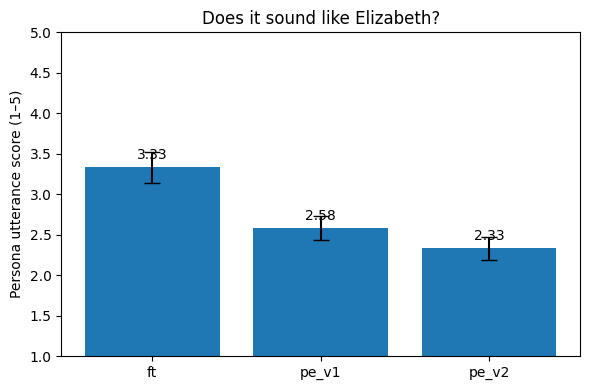

In [9]:
import matplotlib.pyplot as plt

utt = df[df["metric"] == "utterance"].groupby("system")["score"].agg(["mean", "std", "count"])
utt = utt.reindex(["ft", "pe_v1", "pe_v2"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(utt.index, utt["mean"], yerr=utt["std"] / utt["count"]**0.5, capsize=6)
ax.set_ylim(1, 5)
ax.set_ylabel("Persona utterance score (1–5)")
ax.set_title("Does it sound like Elizabeth?")
for i, v in enumerate(utt["mean"]):
    ax.text(i, v + 0.1, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig("utterance_by_system.png", dpi=150)   # ← the blog image
plt.show()

## Takeaways

- Fine-tuning wins on voice (persona utterance) but collapses on hallucination traps — the training data never included a refusal, so the model never learned that Elizabeth can decline a premise.
- All three arms score ~93% on multiple-choice canon questions but fail free recall — a recognition-vs-recall gap. The fine-tune's data taught *how* Elizabeth talks, not *what* happened in the book.
- Voice isn't spine: the fine-tuned model nails Elizabeth's tone but can still cave on pivotal decisions (e.g. Lady Catherine's demands) that its training data never modeled.

**Limitations:** ~100 training pairs is a small SFT set; the eval harness relies on an LLM judge, which has its own biases; MBTI and coherency metrics didn't discriminate between arms and likely need redesigning.

Fine-tuning notebook: [01_finetuning_elizabeth_bennet.ipynb](https://github.com/kritirakheja/elizabeth-bennet-llm/blob/main/01_finetuning_elizabeth_bennet.ipynb)